In [1]:
import pandas as pandas
import numpy as numpy
import matplotlib.pyplot as plt

In [2]:
from nba_api.stats.endpoints import playergamelog

In [3]:
log = playergamelog.PlayerGameLog(
    player_id = "2544",
    season= "2023-24"
)

df_games = log.get_data_frames()[0]
df_games.head()

,SEASON_ID,Player_ID,Game_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,...,DREB,REB,AST,STL,BLK,TOV,PF,PTS,PLUS_MINUS,VIDEO_AVAILABLE
0,22023,2544,0022301195,"Apr 14, 2024",LAL @ NOP,W,38,11,20,0.550,...,9,11,17,5,1,4,0,28,19,1
1,22023,2544,0022301177,"Apr 12, 2024",LAL @ MEM,W,41,13,20,0.650,...,7,9,5,2,0,8,1,37,-3,1
2,22023,2544,0022301155,"Apr 09, 2024",LAL vs. GSW,L,36,14,22,0.636,...,6,7,11,2,0,4,0,33,-6,1
3,22023,2544,0022301127,"Apr 06, 2024",LAL vs. CLE,W,36,10,18,0.556,...,5,5,12,1,1,5,1,24,10,1
4,22023,2544,0022301103,"Apr 03, 2024",LAL @ WAS,W,36,9,18,0.500,...,5,7,9,3,0,4,2,25,9,1


In [4]:
df_games.columns

Index(['SEASON_ID', 'Player_ID', 'Game_ID', 'GAME_DATE', 'MATCHUP', 'WL',
       'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA',
       'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'PF',
       'PTS', 'PLUS_MINUS', 'VIDEO_AVAILABLE'],
      dtype='str')

In [5]:
df_games.info()

<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 27 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   SEASON_ID        71 non-null     str    
 1   Player_ID        71 non-null     int64  
 2   Game_ID          71 non-null     str    
 3   GAME_DATE        71 non-null     str    
 4   MATCHUP          71 non-null     str    
 5   WL               71 non-null     str    
 6   MIN              71 non-null     int64  
 7   FGM              71 non-null     int64  
 8   FGA              71 non-null     int64  
 9   FG_PCT           71 non-null     float64
 10  FG3M             71 non-null     int64  
 11  FG3A             71 non-null     int64  
 12  FG3_PCT          71 non-null     float64
 13  FTM              71 non-null     int64  
 14  FTA              71 non-null     int64  
 15  FT_PCT           71 non-null     float64
 16  OREB             71 non-null     int64  
 17  DREB             71 non-null 

In [6]:
df_games.to_csv("../data/raw/gamelog_bruto.csv", index=False, encoding="utf-8")

In [7]:
df = df_games.copy()

In [8]:
df = df.rename(columns={
    "GAME_DATE": "data_jogo",
    "MATCHUP": "confronto",
    "WL": "resultado",
    "MIN": "minutos",
    "FGM": "cestas_convertidas",
    "FGA": "cestas_tentadas",
    "FG3M": "cestas_3pts",
    "FG3A": "cestas_3pts_tentadas",
    "PTS": "pontos",
    "REB": "rebotes",
    "AST": "assistencias",
    "STL": "roubos",
    "BLK": "tocos"
})

In [9]:
df.columns = df.columns.str.upper()

In [10]:
df = df[[
    "DATA_JOGO",
    "CONFRONTO",
    "RESULTADO",
    "MINUTOS",
    "CESTAS_CONVERTIDAS",
    "CESTAS_TENTADAS",
    "CESTAS_3PTS",
    "CESTAS_3PTS_TENTADAS",
    "PONTOS",
    "REBOTES",
    "ASSISTENCIAS",
    "ROUBOS",
    "TOCOS"
]]

In [11]:
df

,DATA_JOGO,CONFRONTO,RESULTADO,MINUTOS,CESTAS_CONVERTIDAS,CESTAS_TENTADAS,CESTAS_3PTS,CESTAS_3PTS_TENTADAS,PONTOS,REBOTES,ASSISTENCIAS,ROUBOS,TOCOS
0,"Apr 14, 2024",LAL @ NOP,W,38,11,20,0,2,28,11,17,5,1
1,"Apr 12, 2024",LAL @ MEM,W,41,13,20,3,7,37,9,5,2,0
2,"Apr 09, 2024",LAL vs. GSW,L,36,14,22,1,3,33,7,11,2,0
3,"Apr 06, 2024",LAL vs. CLE,W,36,10,18,1,5,24,5,12,1,1
4,"Apr 03, 2024",LAL @ WAS,W,36,9,18,0,1,25,7,9,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
66,"Nov 01, 2023",LAL vs. LAC,W,42,13,19,4,8,35,12,7,1,2
67,"Oct 30, 2023",LAL vs. ORL,W,33,7,17,2,6,19,3,4,3,1
68,"Oct 29, 2023",LAL @ SAC,L,39,11,19,3,8,27,15,8,0,0
69,"Oct 26, 2023",LAL vs. PHX,W,35,7,14,1,5,21,8,9,2,2


In [12]:
df["ADVERSARIO"] = df["CONFRONTO"].str[-3:]

In [13]:
df["ADVERSARIO"]

0     NOP
1     MEM
2     GSW
3     CLE
4     WAS
     ... 
66    LAC
67    ORL
68    SAC
69    PHX
70    DEN
Name: ADVERSARIO, Length: 71, dtype: str

In [14]:
df

,DATA_JOGO,CONFRONTO,RESULTADO,MINUTOS,CESTAS_CONVERTIDAS,CESTAS_TENTADAS,CESTAS_3PTS,CESTAS_3PTS_TENTADAS,PONTOS,REBOTES,ASSISTENCIAS,ROUBOS,TOCOS,ADVERSARIO
0,"Apr 14, 2024",LAL @ NOP,W,38,11,20,0,2,28,11,17,5,1,NOP
1,"Apr 12, 2024",LAL @ MEM,W,41,13,20,3,7,37,9,5,2,0,MEM
2,"Apr 09, 2024",LAL vs. GSW,L,36,14,22,1,3,33,7,11,2,0,GSW
3,"Apr 06, 2024",LAL vs. CLE,W,36,10,18,1,5,24,5,12,1,1,CLE
4,"Apr 03, 2024",LAL @ WAS,W,36,9,18,0,1,25,7,9,3,0,WAS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66,"Nov 01, 2023",LAL vs. LAC,W,42,13,19,4,8,35,12,7,1,2,LAC
67,"Oct 30, 2023",LAL vs. ORL,W,33,7,17,2,6,19,3,4,3,1,ORL
68,"Oct 29, 2023",LAL @ SAC,L,39,11,19,3,8,27,15,8,0,0,SAC
69,"Oct 26, 2023",LAL vs. PHX,W,35,7,14,1,5,21,8,9,2,2,PHX


In [15]:
df["PONTOS_20+"] = df["PONTOS"] >= 20

In [16]:
df["PONTOS_MENOS20"] = df["PONTOS"] < 20

In [17]:
df.isna().sum()

DATA_JOGO               0
CONFRONTO               0
RESULTADO               0
MINUTOS                 0
CESTAS_CONVERTIDAS      0
CESTAS_TENTADAS         0
CESTAS_3PTS             0
CESTAS_3PTS_TENTADAS    0
PONTOS                  0
REBOTES                 0
ASSISTENCIAS            0
ROUBOS                  0
TOCOS                   0
ADVERSARIO              0
PONTOS_20+              0
PONTOS_MENOS20          0
dtype: int64

In [18]:
df

,DATA_JOGO,CONFRONTO,RESULTADO,MINUTOS,CESTAS_CONVERTIDAS,CESTAS_TENTADAS,CESTAS_3PTS,CESTAS_3PTS_TENTADAS,PONTOS,REBOTES,ASSISTENCIAS,ROUBOS,TOCOS,ADVERSARIO,PONTOS_20+,PONTOS_MENOS20
0,"Apr 14, 2024",LAL @ NOP,W,38,11,20,0,2,28,11,17,5,1,NOP,True,False
1,"Apr 12, 2024",LAL @ MEM,W,41,13,20,3,7,37,9,5,2,0,MEM,True,False
2,"Apr 09, 2024",LAL vs. GSW,L,36,14,22,1,3,33,7,11,2,0,GSW,True,False
3,"Apr 06, 2024",LAL vs. CLE,W,36,10,18,1,5,24,5,12,1,1,CLE,True,False
4,"Apr 03, 2024",LAL @ WAS,W,36,9,18,0,1,25,7,9,3,0,WAS,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66,"Nov 01, 2023",LAL vs. LAC,W,42,13,19,4,8,35,12,7,1,2,LAC,True,False
67,"Oct 30, 2023",LAL vs. ORL,W,33,7,17,2,6,19,3,4,3,1,ORL,False,True
68,"Oct 29, 2023",LAL @ SAC,L,39,11,19,3,8,27,15,8,0,0,SAC,True,False
69,"Oct 26, 2023",LAL vs. PHX,W,35,7,14,1,5,21,8,9,2,2,PHX,True,False


In [19]:
#VEZES QUE O LEBRON FEZ 20+ NO TOTAL
print(df["PONTOS_20+"].sum())

#VEZES QUE O LEBRON FEZ 20- NO TOTAL
print(df["PONTOS_MENOS20"].sum())

58
13


In [20]:
#VEZES FEZ 20+ CONTRA CADA ADVERSÁRIO
df.groupby("ADVERSARIO")["PONTOS_20+"].sum().sort_values(ascending=False)

ADVERSARIO
PHX    4
NOP    4
DAL    3
GSW    3
LAC    3
OKC    3
MEM    3
SAC    3
DEN    3
DET    2
CHI    2
ATL    2
WAS    2
TOR    2
POR    2
HOU    2
CLE    2
BKN    2
NYK    2
MIN    2
SAS    2
ORL    1
CHA    1
IND    1
PHI    1
MIA    1
BOS    0
UTA    0
Name: PONTOS_20+, dtype: int64

In [21]:
#VEZES QUE O LEBRON FEZ 20- CONTRA CADA ADVERSÁRIO
df.groupby("ADVERSARIO")["PONTOS_MENOS20"].sum().sort_values(ascending=False)

ADVERSARIO
HOU    2
CHA    1
IND    1
BOS    1
PHI    1
PHX    1
SAC    1
UTA    1
ORL    1
OKC    1
MIA    1
MEM    1
DET    0
GSW    0
DAL    0
DEN    0
CLE    0
CHI    0
BKN    0
ATL    0
NOP    0
NYK    0
LAC    0
MIN    0
POR    0
SAS    0
TOR    0
WAS    0
Name: PONTOS_MENOS20, dtype: int64

In [22]:
#PARTIDAS POR TIME
df["ADVERSARIO"].value_counts()

ADVERSARIO
PHX    5
NOP    4
MEM    4
SAC    4
OKC    4
HOU    4
GSW    3
DEN    3
LAC    3
DAL    3
CLE    2
WAS    2
TOR    2
BKN    2
IND    2
PHI    2
ATL    2
MIN    2
SAS    2
DET    2
CHA    2
NYK    2
CHI    2
POR    2
MIA    2
ORL    2
BOS    1
UTA    1
Name: count, dtype: int64

In [23]:
df.describe()

,MINUTOS,CESTAS_CONVERTIDAS,CESTAS_TENTADAS,CESTAS_3PTS,CESTAS_3PTS_TENTADAS,PONTOS,REBOTES,ASSISTENCIAS,ROUBOS,TOCOS
count,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000
mean,35.323944,9.647887,17.873239,2.098592,5.112676,25.661972,7.295775,8.295775,1.253521,0.535211
std,4.683633,2.624601,3.942188,1.604947,2.314854,6.656777,3.283702,2.820306,1.272998,0.713762
min,23.000000,3.000000,10.000000,0.000000,1.000000,10.000000,0.000000,2.000000,0.000000,0.000000
25%,34.500000,7.500000,15.000000,1.000000,4.000000,21.000000,5.000000,6.000000,0.000000,0.000000
50%,36.000000,10.000000,18.000000,2.000000,5.000000,25.000000,7.000000,8.000000,1.000000,0.000000
75%,38.000000,12.000000,20.000000,3.000000,6.000000,30.000000,9.000000,9.500000,2.000000,1.000000
max,48.000000,15.000000,27.000000,9.000000,12.000000,40.000000,20.000000,17.000000,5.000000,3.000000


In [ ]:
# VE A MEDIA DO LEBRON NA TEMPORADA
media_temporada = df[[
    "PONTOS",
    "ASSISTENCIAS",
    "REBOTES",
    "ROUBOS",
    "TOCOS"
]].mean()

media_temporada

PONTOS          25.661972
ASSISTENCIAS     8.295775
REBOTES          7.295775
ROUBOS           1.253521
TOCOS            0.535211
dtype: float64

In [27]:
# VE A MEDIA DO LEBRON NA TEMPORADA POR ADVERSARIO

media_por_time = df.groupby("ADVERSARIO")[[
    "PONTOS",
    "ASSISTENCIAS",
    "REBOTES",
    "ROUBOS",
    "TOCOS"
]].mean().sort_values("PONTOS", ascending=False)

media_por_time

,PONTOS,ASSISTENCIAS,REBOTES,ROUBOS,TOCOS
ADVERSARIO,,,,,
GSW,36.333333,10.666667,11.666667,1.000000,0.333333
BKN,32.000000,5.000000,9.000000,0.000000,0.000000
POR,31.500000,7.000000,5.000000,1.000000,0.000000
LAC,31.333333,7.333333,8.666667,0.666667,1.333333
NOP,28.250000,11.750000,6.250000,1.500000,0.750000
WAS,28.000000,9.000000,5.500000,2.000000,0.500000
DAL,28.000000,8.000000,8.333333,1.333333,0.333333
MIN,27.500000,7.500000,5.500000,1.500000,0.500000
MEM,27.000000,7.500000,9.250000,2.250000,0.000000


In [28]:
comparacao = media_por_time - media_temporada

comparacao

,PONTOS,ASSISTENCIAS,REBOTES,ROUBOS,TOCOS
ADVERSARIO,,,,,
GSW,10.671362,2.370892,4.370892,-0.253521,-0.201878
BKN,6.338028,-3.295775,1.704225,-1.253521,-0.535211
POR,5.838028,-1.295775,-2.295775,-0.253521,-0.535211
LAC,5.671362,-0.962441,1.370892,-0.586854,0.798122
NOP,2.588028,3.454225,-1.045775,0.246479,0.214789
WAS,2.338028,0.704225,-1.795775,0.746479,-0.035211
DAL,2.338028,-0.295775,1.037559,0.079812,-0.201878
MIN,1.838028,-0.795775,-1.795775,0.246479,-0.035211
MEM,1.338028,-0.795775,1.954225,0.996479,-0.535211


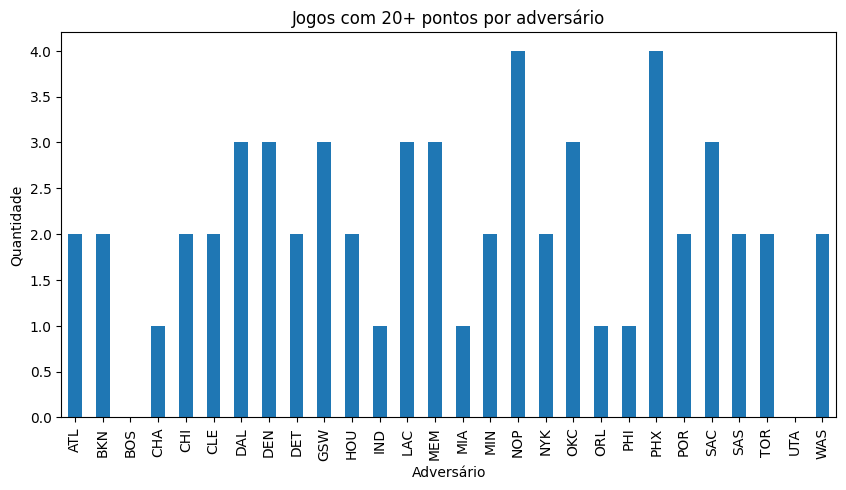

In [30]:
#gráfico 1 — jogos com 20+ pontos por adversário
df.groupby("ADVERSARIO")["PONTOS_20+"].sum().plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Jogos com 20+ pontos por adversário")
plt.xlabel("Adversário")
plt.ylabel("Quantidade")

plt.show()